# MMLU Solver/Judge Difficulty Comparison

Load MMLU K-factor item difficulty JSONs and keep each item's per-model scores. `mmlu_solver` is solver-side; `mmlu_judging` is judge-side. MMLU judging has `original` and `swapped` rows, so judging difficulty and judging scores are averaged to one row per `pair_id` before joining to solver items.


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 240)


## Choose K And Resolve Paths


In [2]:
MODEL_SELECTION_METRIC = "loss"  # lower held-out log loss is better
K = None  # set below from model selection



def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "K-Factor").exists() and (candidate / "benchmarks").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing K-Factor/ and benchmarks/")


REPO_ROOT = find_repo_root()
print(f"Repo root: {REPO_ROOT}")

solver_json_path = REPO_ROOT / "K-Factor" / "results" / "mmlu_solver" / "mmlu_solver_kfactor_item_difficulties_with_laplace_uncertainty.json"
judge_json_path = REPO_ROOT / "K-Factor" / "results" / "mmlu_judging" / "mmlu_judging_kfactor_item_difficulties_with_laplace_uncertainty.json"
solver_fit_summary_path = REPO_ROOT / "K-Factor" / "results" / "mmlu_solver" / "mmlu_solver_kfactor_fit_summary.csv"
judge_fit_summary_path = REPO_ROOT / "K-Factor" / "results" / "mmlu_judging" / "mmlu_judging_kfactor_fit_summary.csv"
question_path = REPO_ROOT / "benchmarks" / "mmlu" / "judgebench_mmlu_pro_questions_unique.csv"

out_dir = REPO_ROOT / "K-Factor" / "results" / "mmlu_solver_judge_comparison"
out_dir.mkdir(parents=True, exist_ok=True)

for path in [solver_json_path, judge_json_path, solver_fit_summary_path, judge_fit_summary_path, question_path]:
    print(path.relative_to(REPO_ROOT), path.exists())


Repo root: /Users/dkoffical/Documents/GitHub/cs321m_project
K-Factor/results/mmlu_solver/mmlu_solver_kfactor_item_difficulties_with_laplace_uncertainty.json True
K-Factor/results/mmlu_judging/mmlu_judging_kfactor_item_difficulties_with_laplace_uncertainty.json True
K-Factor/results/mmlu_solver/mmlu_solver_kfactor_fit_summary.csv True
K-Factor/results/mmlu_judging/mmlu_judging_kfactor_fit_summary.csv True
benchmarks/mmlu/judgebench_mmlu_pro_questions_unique.csv True


## Fit Summaries


In [3]:
solver_fit_summary = pd.read_csv(solver_fit_summary_path)
judge_fit_summary = pd.read_csv(judge_fit_summary_path)

def choose_best_k(summary, metric="loss"):
    if metric == "loss":
        sort_cols = [c for c in ["loss", "brier", "ece", "auc"] if c in summary.columns]
        ascending = [True, True, True, False][:len(sort_cols)]
        return summary.sort_values(sort_cols, ascending=ascending).iloc[0]
    if metric == "auc":
        return summary.sort_values(["auc", "ece", "loss"], ascending=[False, True, True]).iloc[0]
    raise ValueError(f"Unknown model-selection metric: {metric}")

solver_best = choose_best_k(solver_fit_summary, MODEL_SELECTION_METRIC)
judge_best = choose_best_k(judge_fit_summary, MODEL_SELECTION_METRIC)
solver_selected_k = int(solver_best["k"])
judge_selected_k = int(judge_best["k"])
if solver_selected_k != judge_selected_k:
    raise ValueError(
        f"This notebook expects shared K, but loss selected solver K={solver_selected_k}, judge K={judge_selected_k}."
    )
K = solver_selected_k

print(f"Model selection metric: held-out {MODEL_SELECTION_METRIC}")
print(f"Solver-side best k: k={solver_selected_k}")
print(f"Judge-side best k:  k={judge_selected_k}")
print(f"Currently loading K={K}")

print()
print("Solver fit summary")
display(solver_fit_summary.round(4))

print("Judge fit summary")
display(judge_fit_summary.round(4))

solver_fit_summary.to_csv(out_dir / "mmlu_solver_kfactor_fit_summary.csv", index=False)
judge_fit_summary.to_csv(out_dir / "mmlu_judge_kfactor_fit_summary.csv", index=False)


Model selection metric: held-out loss
Solver-side best k: k=1
Judge-side best k:  k=1
Currently loading K=1

Solver fit summary


,k,loss,loss_std,auc,auc_std,log_likelihood,log_likelihood_std,brier,brier_std,ece,ece_std,final_train_loss,final_train_auc,final_train_log_likelihood,final_train_brier,final_train_ece
0,1,1.7460,NaN,0.7399,NaN,-1.7460,NaN,0.2625,NaN,0.2069,NaN,0.3583,0.8841,-0.3583,0.1208,0.0361
1,2,2.9074,NaN,0.6700,NaN,-2.9074,NaN,0.3245,NaN,0.3126,NaN,0.2160,0.9716,-0.2160,0.0706,0.0249


Judge fit summary


,k,loss,loss_std,auc,auc_std,log_likelihood,log_likelihood_std,brier,brier_std,ece,ece_std,final_train_loss,final_train_auc,final_train_log_likelihood,final_train_brier,final_train_ece
0,1,0.9731,NaN,0.7786,NaN,-0.9731,NaN,0.1659,NaN,0.1237,NaN,0.2308,0.9463,-0.2308,0.0768,0.0298
1,2,1.2960,NaN,0.8008,NaN,-1.2960,NaN,0.1585,NaN,0.1451,NaN,0.1152,0.9876,-0.1152,0.0359,0.0169


## Load Item Difficulties And Scores


In [4]:
def load_kfactor_fit(json_path, k, score_col):
    with open(json_path) as f:
        payload = json.load(f)

    fit_key = f"k{k}"
    if fit_key not in payload["fits"]:
        raise KeyError(f"{json_path} does not contain {fit_key}; available={list(payload['fits'])}")

    df = pd.DataFrame(payload["fits"][fit_key])
    df["item_id"] = df["item_id"].astype(str)
    df["pair_id"] = df["pair_id"].astype(str)
    df = df.rename(columns={"scores": score_col})
    return df, payload


solver_items, solver_payload = load_kfactor_fit(solver_json_path, K, "solver_scores")
judge_order_items, judge_payload = load_kfactor_fit(judge_json_path, K, "judge_order_scores")

print(f"solver_items:      {solver_items.shape}")
print(f"judge_order_items: {judge_order_items.shape}")

solver_items.to_csv(out_dir / f"mmlu_k{K}_solver_items.csv", index=False)
solver_items.to_json(out_dir / f"mmlu_k{K}_solver_items.json", orient="records", indent=2, force_ascii=False)
judge_order_items.to_csv(out_dir / f"mmlu_k{K}_judge_order_items.csv", index=False)
judge_order_items.to_json(out_dir / f"mmlu_k{K}_judge_order_items.json", orient="records", indent=2, force_ascii=False)


solver_items:      (154, 16)
judge_order_items: (308, 19)


## Attach Prompt Text


In [5]:
def split_pair_ids(value):
    if pd.isna(value) or str(value).strip() == "":
        return []
    text = str(value)
    for sep in [";", "|"]:
        text = text.replace(sep, ",")
    return [x.strip() for x in text.split(",") if x.strip()]

questions = pd.read_csv(question_path)
prompt_rows = []
for _, row in questions.iterrows():
    for pair_col, label_col, split_name in [
        ("gpt_pair_ids", "gpt_labels", "gpt"),
        ("claude_pair_ids", "claude_labels", "claude"),
    ]:
        for pair_id in split_pair_ids(row.get(pair_col)):
            prompt_rows.append({
                "pair_id": pair_id,
                "question_index": row.get("question_index"),
                "original_ids": row.get("original_ids"),
                "question_source": row.get("source"),
                "question_split": split_name,
                "gold_label": row.get(label_col),
                "prompt": row.get("question"),
            })

prompt_lookup = pd.DataFrame(prompt_rows).drop_duplicates("pair_id")
print(f"prompt_lookup: {prompt_lookup.shape}")

solver_items = solver_items.merge(prompt_lookup, on="pair_id", how="left")
judge_order_items = judge_order_items.merge(
    prompt_lookup.drop(columns=["gold_label"], errors="ignore"),
    on="pair_id",
    how="left",
    suffixes=("", "_prompt"),
)

print(f"solver prompts missing: {solver_items['prompt'].isna().sum()}")
print(f"judge prompts missing:  {judge_order_items['prompt'].isna().sum()}")

display(solver_items.head())


prompt_lookup: (308, 7)
solver prompts missing: 0
judge prompts missing:  0


,item_id,difficulty,difficulty_centered,easiness_z,loading_factor_1,dominant_factor,item_id_meta,pair_id,source,split,gold_letter,difficulty_laplace_se,difficulty_centered_laplace_se,difficulty_centered_laplace_lo,difficulty_centered_laplace_hi,solver_scores,question_index,original_ids,question_source,question_split,gold_label,prompt
0,7978,8.713128,8.128340,-8.713128,-8.822929,factor_1,7978,bd6f87f2-cb60-58b3-8b27-4eceab2bfc79,mmlu-pro-math,gpt,B,2.827072,2.824274,2.592763,13.663916,"{'claude_haiku_4_5_20251001': 0.0, 'claude_sonnet_4_6': 0.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 1.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 1.0, 'qwen_qwen3_5_0_8b...",172,7978,mmlu-pro-math,gpt,A>B,"Let $X_1, X_2, \ldots$ be a sequence of independent indetically distributed random variables drawn according to the probability mass function $p(x) = N(0,1)$. Let $q(x)=N(1,1)$ be another probability mass function. Use natural logarithm..."
1,2934,8.517432,7.932643,-8.517432,15.463758,factor_1,2934,6c5f9b09-193f-5070-9dfd-2dee1f69a9a3,mmlu-pro-biology,gpt,F,3.860030,3.846337,0.393823,15.471464,"{'claude_haiku_4_5_20251001': 1.0, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.0, 'qwen_qwen3_5_0_8b...",4,2934,mmlu-pro-biology,gpt,B>A,"A stem-boring beetle has laid its eggs in the center of a 5-year-old wood twig, and the eggs have matured into larvae. In proper order (inside to outside), what tissues and tissue regions would the larvae encounter as they eat their way..."
2,9524,7.165370,6.580581,-7.165370,2.333959,factor_1,9524,34e8d16b-9824-5373-b735-d25a3df21044,mmlu-pro-physics,gpt,I,13.330700,13.247175,-19.383884,32.545044,"{'claude_haiku_4_5_20251001': 0.0, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.0, 'qwen_qwen3_5_0_8b...",231,9524,mmlu-pro-physics,gpt,B>A,The constant b in vanderWaals' equation for helium is 23.4 cm^3 \textbullet mole^-1. Obtain an estimate of the diameter of a helium molecule.\n(A) 5.78 Å\n(B) 3.92 Å\n(C) 4.12 Å\n(D) 0.98 Å\n(E) 2.00 Å\n(F) 2.34 A\n(G) 3.26 A\n(H) 1.98 ...
3,1330,6.544123,5.959334,-6.544123,2.132421,factor_1,1330,50e6565c-07f5-57d6-80d8-028498a1251b,mmlu-pro-law,gpt,H,8.845990,8.793365,-11.275662,23.194332,"{'claude_haiku_4_5_20251001': 0.0, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.0, 'qwen_qwen3_5_0_8b...",160,1330,mmlu-pro-law,gpt,B>A,"A debtor owed a creditor $12,000 under a promissory note. Under the applicable statute of limitations, a suit to collect on the promissory note had to have been filed by September 30 of last year. On June 1 of this year, the creditor re..."
4,6222,6.530421,5.945632,-6.530421,2.099140,factor_1,6222,1c76021c-cb8e-5477-8f7e-88855d6dd547,mmlu-pro-health,gpt,J,7.558568,7.515182,-8.784124,20.675388,"{'claude_haiku_4_5_20251001': 0.0, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.0, 'qwen_qwen3_5_0_8b...",119,6222,mmlu-pro-health,gpt,A>B,Which one of the following statements about the growth of the mandible is correct?\n(A) The functional matrix acting on the angle of the mandible is the medial pterygoid muscle\n(B) The mental symphysis never fully closes\n(C) The ossif...


## Aggregate Judging Original/Swapped Rows


In [6]:
def mean_score_dict(dicts):
    models = sorted({model for scores in dicts if isinstance(scores, dict) for model in scores})
    averaged = {}
    for model in models:
        vals = []
        for scores in dicts:
            if isinstance(scores, dict):
                val = scores.get(model)
                if val is not None and not pd.isna(val):
                    vals.append(float(val))
        averaged[model] = float(np.mean(vals)) if vals else None
    return averaged


def combine_se_for_mean(values):
    vals = pd.Series(values).dropna().astype(float)
    if vals.empty:
        return np.nan
    return float(np.sqrt(np.square(vals).sum()) / len(vals))


def aggregate_judge_pair(group):
    return pd.Series({
        "judge_item_ids": list(group["item_id"].astype(str)),
        "judge_orders": list(group["order"].astype(str)),
        "judge_source": group["source"].iloc[0],
        "judge_split": group["split"].iloc[0],
        "judge_response_model": group["response_model"].iloc[0],
        "judge_gold_labels": dict(zip(group["order"].astype(str), group["gold_label"].astype(str))),
        "judge_difficulty": group["difficulty"].mean(),
        "judge_difficulty_centered": group["difficulty_centered"].mean(),
        "judge_difficulty_laplace_se": combine_se_for_mean(group["difficulty_laplace_se"]),
        "judge_difficulty_centered_laplace_se": combine_se_for_mean(group["difficulty_centered_laplace_se"]),
        "judge_dominant_factors": dict(zip(group["order"].astype(str), group["dominant_factor"].astype(str))),
        "judge_scores": mean_score_dict(group["judge_order_scores"]),
        "prompt": group["prompt"].dropna().iloc[0] if group["prompt"].notna().any() else None,
    })


judge_items = (
    judge_order_items
    .groupby("pair_id", as_index=False)
    .apply(aggregate_judge_pair, include_groups=False)
    .reset_index(drop=True)
)

print(f"judge_items aggregated: {judge_items.shape}")
display(judge_items.head())

judge_items.to_csv(out_dir / f"mmlu_k{K}_judge_items_aggregated.csv", index=False)
judge_items.to_json(out_dir / f"mmlu_k{K}_judge_items_aggregated.json", orient="records", indent=2, force_ascii=False)


judge_items aggregated: (154, 14)


,pair_id,judge_item_ids,judge_orders,judge_source,judge_split,judge_response_model,judge_gold_labels,judge_difficulty,judge_difficulty_centered,judge_difficulty_laplace_se,judge_difficulty_centered_laplace_se,judge_dominant_factors,judge_scores,prompt
0,000ad3d2-6b2a-5bee-baf2-fdf780b4e068,"[8315:original, 8315:swapped]","[original, swapped]",mmlu-pro-math,gpt,gpt-4o-2024-05-13,"{'original': 'A>B', 'swapped': 'B>A'}",-5.185997,-4.121625,4.222241,4.212587,"{'original': 'factor_1', 'swapped': 'factor_1'}","{'claude_haiku_4_5_20251001': 1.0, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 1.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 1.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 1.0, 'qwen_qwen3_5_0_8b...",Let $x_1$ and $x_2$ be the roots of the equation $x^2 + 3x + 1 =0$. Compute $(x_1/(x_2 + 1))^2 + (x_2 / (x_1 + 1))^2$.\n(A) 24.0\n(B) 25.0\n(C) 17.0\n(D) 18.0\n(E) 19.0\n(F) 22.0\n(G) 21.0\n(H) 23.0\n(I) 20.0\n(J) 16.0\nIf you cannot de...
1,01fb6121-e025-5251-a55f-f903c79e4ec6,"[1803:swapped, 1803:original]","[swapped, original]",mmlu-pro-law,gpt,gpt-4o-2024-05-13,"{'swapped': 'B>A', 'original': 'A>B'}",2.919889,3.984261,0.751284,0.771424,"{'swapped': 'factor_1', 'original': 'factor_1'}","{'claude_haiku_4_5_20251001': 1.0, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 1.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.5, 'mistralai_ministral_3_8b_instruct_2512_bf16': 1.0, 'qwen_qwen3_5_0_8b...","A person owned property next to a highway. After raking leaves on his property into a large pile, the landowner loaded the leaves into several large metal barrels so that he could burn the leaves. Before starting the fire, the landowner..."
2,02c8d6ef-f58a-5bf5-8b05-0a6719e16f20,"[3776:original, 3776:swapped]","[original, swapped]",mmlu-pro-chemistry,gpt,gpt-4o-2024-05-13,"{'original': 'B>A', 'swapped': 'A>B'}",-0.642653,0.421718,2.116333,2.117572,"{'original': 'factor_1', 'swapped': 'factor_1'}","{'claude_haiku_4_5_20251001': 1.0, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 1.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.5, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.5, 'qwen_qwen3_5_0_8b...",A .05molalKClsolution is electrolyzed in aHittorfcell at 25°C. A silver coulometer connected in series with the cell deposited .4068g of silver. The anode solution of theHittorf cell weighed 132.9g and was found to contain 186mg of pota...
3,05ea6065-69da-58b9-a53b-872e8d940915,"[1978:original, 1978:swapped]","[original, swapped]",mmlu-pro-law,gpt,gpt-4o-2024-05-13,"{'original': 'B>A', 'swapped': 'A>B'}",-2.046583,-0.982212,6.110694,6.093640,"{'original': 'factor_1', 'swapped': 'factor_1'}","{'claude_haiku_4_5_20251001': 1.0, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 1.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 1.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 1.0, 'qwen_qwen3_5_0_8b...","A grantor is the fee simple owner of a 1,000-acre tract of land. Half of the tract is swampland totally unfit for cultivation, though it is heavily covered with valuable hardwood timber. The other half is also covered with valuable timb..."
4,07019bab-fc3e-5c91-ac9c-36869cfe79b0,"[7403:original, 7403:swapped]","[original, swapped]",mmlu-pro-economics,gpt,gpt-4o-2024-05-13,"{'original': 'B>A', 'swapped': 'A>B'}",5.978380,7.042751,2.972771,2.968891,"{'original': 'factor_1', 'swapped': 'factor_1'}","{'claude_haiku_4_5_20251001': 0.5, 'claude_sonnet_4_6': 0.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.5, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.5, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.5, 'qwen_qwen3_5_0_8b...",What is a margin requirement?\n(A) The financial reserve a trader must maintain to cover potential losses on leveraged positions\n(B) Percentage of the value of a stock purchase required to be paid immediately\n(C) The maximum percentag...


## Join Solver And Judge Items


In [7]:
def prefix_solver_cols(df):
    return df.rename(columns={col: f"solver_{col}" for col in df.columns if col != "solver_scores"})


def prefix_judge_cols(df):
    rename = {}
    for col in df.columns:
        if col == "judge_scores":
            continue
        if col == "pair_id":
            rename[col] = "judge_pair_id"
        elif col.startswith("judge_"):
            continue
        else:
            rename[col] = f"judge_{col}"
    return df.rename(columns=rename)


solver_for_join = prefix_solver_cols(solver_items)
judge_for_join = prefix_judge_cols(judge_items)

paired_items = solver_for_join.merge(
    judge_for_join,
    left_on="solver_pair_id",
    right_on="judge_pair_id",
    how="inner",
    validate="one_to_one",
)

print(f"paired_items: {paired_items.shape}")
display(paired_items.head())

paired_items.to_csv(out_dir / f"mmlu_k{K}_paired_items.csv", index=False)
paired_items.to_json(out_dir / f"mmlu_k{K}_paired_items.json", orient="records", indent=2, force_ascii=False)


paired_items: (154, 36)


,solver_item_id,solver_difficulty,solver_difficulty_centered,solver_easiness_z,solver_loading_factor_1,solver_dominant_factor,solver_item_id_meta,solver_pair_id,solver_source,solver_split,solver_gold_letter,solver_difficulty_laplace_se,solver_difficulty_centered_laplace_se,solver_difficulty_centered_laplace_lo,solver_difficulty_centered_laplace_hi,solver_scores,solver_question_index,solver_original_ids,solver_question_source,solver_question_split,solver_gold_label,solver_prompt,judge_pair_id,judge_item_ids,judge_orders,judge_source,judge_split,judge_response_model,judge_gold_labels,judge_difficulty,judge_difficulty_centered,judge_difficulty_laplace_se,judge_difficulty_centered_laplace_se,judge_dominant_factors,judge_scores,judge_prompt
0,7978,8.713128,8.128340,-8.713128,-8.822929,factor_1,7978,bd6f87f2-cb60-58b3-8b27-4eceab2bfc79,mmlu-pro-math,gpt,B,2.827072,2.824274,2.592763,13.663916,"{'claude_haiku_4_5_20251001': 0.0, 'claude_sonnet_4_6': 0.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 1.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 1.0, 'qwen_qwen3_5_0_8b...",172,7978,mmlu-pro-math,gpt,A>B,"Let $X_1, X_2, \ldots$ be a sequence of independent indetically distributed random variables drawn according to the probability mass function $p(x) = N(0,1)$. Let $q(x)=N(1,1)$ be another probability mass function. Use natural logarithm...",bd6f87f2-cb60-58b3-8b27-4eceab2bfc79,"[7978:swapped, 7978:original]","[swapped, original]",mmlu-pro-math,gpt,gpt-4o-2024-05-13,"{'swapped': 'B>A', 'original': 'A>B'}",-0.502889,0.561482,6.450019,6.431713,"{'swapped': 'factor_1', 'original': 'factor_1'}","{'claude_haiku_4_5_20251001': 0.5, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.5, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.5, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.5, 'qwen_qwen3_5_0_8b...","Let $X_1, X_2, \ldots$ be a sequence of independent indetically distributed random variables drawn according to the probability mass function $p(x) = N(0,1)$. Let $q(x)=N(1,1)$ be another probability mass function. Use natural logarithm..."
1,2934,8.517432,7.932643,-8.517432,15.463758,factor_1,2934,6c5f9b09-193f-5070-9dfd-2dee1f69a9a3,mmlu-pro-biology,gpt,F,3.860030,3.846337,0.393823,15.471464,"{'claude_haiku_4_5_20251001': 1.0, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.0, 'qwen_qwen3_5_0_8b...",4,2934,mmlu-pro-biology,gpt,B>A,"A stem-boring beetle has laid its eggs in the center of a 5-year-old wood twig, and the eggs have matured into larvae. In proper order (inside to outside), what tissues and tissue regions would the larvae encounter as they eat their way...",6c5f9b09-193f-5070-9dfd-2dee1f69a9a3,"[2934:original, 2934:swapped]","[original, swapped]",mmlu-pro-biology,gpt,gpt-4o-2024-05-13,"{'original': 'B>A', 'swapped': 'A>B'}",-1.811982,-0.747611,0.676297,0.699099,"{'original': 'factor_1', 'swapped': 'factor_1'}","{'claude_haiku_4_5_20251001': 0.5, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 1.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.5, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.5, 'qwen_qwen3_5_0_8b...","A stem-boring beetle has laid its eggs in the center of a 5-year-old wood twig, and the eggs have matured into larvae. In proper order (inside to outside), what tissues and tissue regions would the larvae encounter as they eat their way..."
2,9524,7.165370,6.580581,-7.165370,2.333959,factor_1,9524,34e8d16b-9824-5373-b735-d25a3df21044,mmlu-pro-physics,gpt,I,13.330700,13.247175,-19.383884,32.545044,"{'claude_haiku_4_5_20251001': 0.0, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.0, 'qwen_qwen3_5_0_8b...",231,9524,mmlu-pro-physics,gpt,B>A

## Part One: Solver Difficulty vs Mean Judging Score


In [8]:
partone_table = paired_items[[
    "solver_item_id",
    "solver_pair_id",
    "solver_source",
    "solver_difficulty_centered",
    "solver_difficulty_centered_laplace_se",
    "solver_prompt",
    "solver_gold_letter",
    "solver_scores",
    "judge_scores",
]].copy()

partone_table["judge_score_mean"] = partone_table["judge_scores"].apply(
    lambda scores: pd.Series(scores).dropna().mean()
)

partone_table_sorted = partone_table.sort_values("solver_difficulty_centered", ascending=False)

display(partone_table_sorted.head())

partone_table.to_csv(out_dir / f"mmlu_k{K}_partone_table_with_judge_score_mean.csv", index=False)
partone_table.to_json(out_dir / f"mmlu_k{K}_partone_table_with_judge_score_mean.json", orient="records", indent=2, force_ascii=False)
partone_table_sorted.to_csv(out_dir / f"mmlu_k{K}_partone_table_sorted.csv", index=False)
partone_table_sorted.to_json(out_dir / f"mmlu_k{K}_partone_table_sorted.json", orient="records", indent=2, force_ascii=False)


,solver_item_id,solver_pair_id,solver_source,solver_difficulty_centered,solver_difficulty_centered_laplace_se,solver_prompt,solver_gold_letter,solver_scores,judge_scores,judge_score_mean
0,7978,bd6f87f2-cb60-58b3-8b27-4eceab2bfc79,mmlu-pro-math,8.128340,2.824274,"Let $X_1, X_2, \ldots$ be a sequence of independent indetically distributed random variables drawn according to the probability mass function $p(x) = N(0,1)$. Let $q(x)=N(1,1)$ be another probability mass function. Use natural logarithm...",B,"{'claude_haiku_4_5_20251001': 0.0, 'claude_sonnet_4_6': 0.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 1.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 1.0, 'qwen_qwen3_5_0_8b...","{'claude_haiku_4_5_20251001': 0.5, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.5, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.5, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.5, 'qwen_qwen3_5_0_8b...",0.70
1,2934,6c5f9b09-193f-5070-9dfd-2dee1f69a9a3,mmlu-pro-biology,7.932643,3.846337,"A stem-boring beetle has laid its eggs in the center of a 5-year-old wood twig, and the eggs have matured into larvae. In proper order (inside to outside), what tissues and tissue regions would the larvae encounter as they eat their way...",F,"{'claude_haiku_4_5_20251001': 1.0, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.0, 'qwen_qwen3_5_0_8b...","{'claude_haiku_4_5_20251001': 0.5, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 1.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.5, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.5, 'qwen_qwen3_5_0_8b...",0.70
2,9524,34e8d16b-9824-5373-b735-d25a3df21044,mmlu-pro-physics,6.580581,13.247175,The constant b in vanderWaals' equation for helium is 23.4 cm^3 \textbullet mole^-1. Obtain an estimate of the diameter of a helium molecule.\n(A) 5.78 Å\n(B) 3.92 Å\n(C) 4.12 Å\n(D) 0.98 Å\n(E) 2.00 Å\n(F) 2.34 A\n(G) 3.26 A\n(H) 1.98 ...,I,"{'claude_haiku_4_5_20251001': 0.0, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.0, 'qwen_qwen3_5_0_8b...","{'claude_haiku_4_5_20251001': 0.0, 'claude_sonnet_4_6': 0.5, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.5, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.5, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.5, 'qwen_qwen3_5_0_8b...",0.30
3,1330,50e6565c-07f5-57d6-80d8-028498a1251b,mmlu-pro-law,5.959334,8.793365,"A debtor owed a creditor $12,000 under a promissory note. Under the applicable statute of limitations, a suit to collect on the promissory note had to have been filed by September 30 of last year. On June 1 of this year, the creditor re...",H,"{'claude_haiku_4_5_20251001': 0.0, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.0, 'qwen_qwen3_5_0_8b...","{'claude_haiku_4_5_20251001': 1.0, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 1.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 1.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 1.0, 'qwen_qwen3_5_0_8b...",0.90
4,6222,1c76021c-cb8e-5477-8f7e-88855d6dd547,mmlu-pro-health,5.945632,7.515182,Which one of the following statements about the growth of the mandible is correct?\n(A) The functional matrix acting on the angle of the mandible is the medial pterygoid muscle\n(B) The mental symphysis never fully closes\n(C) The ossif...,J,"{'claude_haiku_4_5_20251001': 0.0, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.0, 'qwen_qwen3_5_0_8b...","{'claude_h

## Judge Score By Solver Difficulty Decile


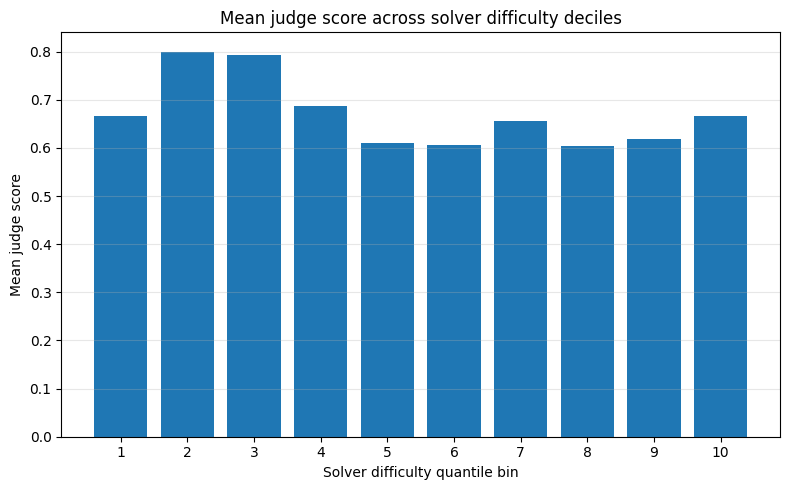

,difficulty_bin,solver_difficulty_mean,judge_score_mean,n_items
0,1,-4.860811,0.665625,16
1,2,-1.933830,0.800000,15
2,3,-1.282477,0.793333,15
3,4,-0.767788,0.687500,16
4,5,-0.400949,0.610000,15
5,6,-0.066648,0.605556,15
6,7,0.307344,0.656250,16
7,8,0.967337,0.603333,15
8,9,2.399197,0.618148,15
9,10,5.618789,0.665625,16


In [9]:
plot_df = partone_table.copy()

plot_df["difficulty_bin"] = pd.qcut(
    plot_df["solver_difficulty_centered"],
    q=10,
    labels=False,
    duplicates="drop",
)

bin_summary = (
    plot_df
    .groupby("difficulty_bin", observed=True)
    .agg(
        solver_difficulty_mean=("solver_difficulty_centered", "mean"),
        judge_score_mean=("judge_score_mean", "mean"),
        n_items=("solver_item_id", "count"),
    )
    .reset_index()
)

bin_summary["difficulty_bin"] = bin_summary["difficulty_bin"] + 1

plt.figure(figsize=(8, 5))
plt.bar(bin_summary["difficulty_bin"], bin_summary["judge_score_mean"])
plt.xlabel("Solver difficulty quantile bin")
plt.ylabel("Mean judge score")
plt.title("Mean judge score across solver difficulty deciles")
plt.xticks(bin_summary["difficulty_bin"])
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(out_dir / f"mmlu_k{K}_difficulty_bin_summary.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / f"mmlu_k{K}_difficulty_bin_summary.pdf", bbox_inches="tight")
plt.show()

display(bin_summary)

bin_summary.to_csv(out_dir / f"mmlu_k{K}_difficulty_bin_summary.csv", index=False)
bin_summary.to_json(out_dir / f"mmlu_k{K}_difficulty_bin_summary.json", orient="records", indent=2, force_ascii=False)


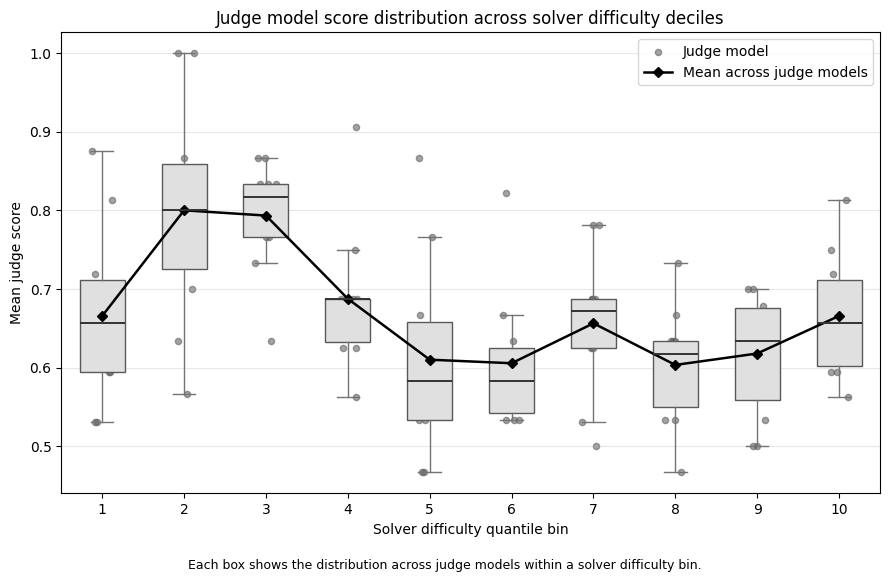

,difficulty_bin,judge_model,judge_score_mean,n_items
0,1,claude_haiku_4_5_20251001,0.68750,16
1,1,claude_sonnet_4_6,0.87500,16
2,1,mistralai_ministral_3_14b_instruct_2512_bf16,0.62500,16
3,1,mistralai_ministral_3_3b_instruct_2512_bf16,0.53125,16
4,1,mistralai_ministral_3_8b_instruct_2512_bf16,0.71875,16
...,...,...,...,...
95,10,qwen_qwen3_5_0_8b,0.59375,16
96,10,qwen_qwen3_5_27b,0.75000,16
97,10,qwen_qwen3_5_2b,0.56250,16
98,10,qwen_qwen3_5_4b,0.68750,16


,difficulty_bin,judge_score_mean,judge_score_sd,n_judge_models
0,1,0.665625,0.114156,10
1,2,0.800000,0.140546,10
2,3,0.793333,0.071665,10
3,4,0.687500,0.091998,10
4,5,0.610000,0.128668,10
5,6,0.605476,0.088092,10
6,7,0.656250,0.091998,10
7,8,0.603333,0.076093,10
8,9,0.617857,0.078321,10
9,10,0.665625,0.078021,10


In [10]:
# Per-judge-model view of Part 1.
# Each box shows the distribution across judge models within a solver difficulty bin.
model_plot_df = partone_table.copy()
model_plot_df["difficulty_bin"] = pd.qcut(
    model_plot_df["solver_difficulty_centered"],
    q=10,
    labels=False,
    duplicates="drop",
)
model_plot_df["difficulty_bin"] = model_plot_df["difficulty_bin"] + 1

judge_model_rows = []
for _, row in model_plot_df.iterrows():
    scores = row["judge_scores"]
    if not isinstance(scores, dict):
        continue
    for judge_model, score in scores.items():
        if score is None or pd.isna(score):
            continue
        judge_model_rows.append({
            "difficulty_bin": int(row["difficulty_bin"]),
            "solver_item_id": row["solver_item_id"],
            "judge_model": judge_model,
            "judge_score": float(score),
        })

judge_model_scores = pd.DataFrame(judge_model_rows)
judge_model_bin_summary = (
    judge_model_scores
    .groupby(["difficulty_bin", "judge_model"], observed=True)
    .agg(
        judge_score_mean=("judge_score", "mean"),
        n_items=("solver_item_id", "count"),
    )
    .reset_index()
)

judge_model_bin_mean = (
    judge_model_bin_summary
    .groupby("difficulty_bin", observed=True)
    .agg(
        judge_score_mean=("judge_score_mean", "mean"),
        judge_score_sd=("judge_score_mean", "std"),
        n_judge_models=("judge_model", "count"),
    )
    .reset_index()
)

bins = sorted(judge_model_bin_summary["difficulty_bin"].unique())
box_values = [
    judge_model_bin_summary.loc[
        judge_model_bin_summary["difficulty_bin"] == bin_id,
        "judge_score_mean",
    ].dropna().to_numpy()
    for bin_id in bins
]

rng = np.random.default_rng(123)
plot_x = judge_model_bin_summary["difficulty_bin"].to_numpy(dtype=float)
plot_x = plot_x + rng.uniform(-0.14, 0.14, size=len(plot_x))

plt.figure(figsize=(9, 5.8))
plt.boxplot(
    box_values,
    positions=bins,
    widths=0.55,
    patch_artist=True,
    showfliers=False,
    boxprops={"facecolor": "0.88", "edgecolor": "0.35", "linewidth": 1.0},
    medianprops={"color": "0.2", "linewidth": 1.4},
    whiskerprops={"color": "0.45", "linewidth": 1.0},
    capprops={"color": "0.45", "linewidth": 1.0},
)
plt.scatter(
    plot_x,
    judge_model_bin_summary["judge_score_mean"],
    s=20,
    color="0.35",
    alpha=0.55,
    label="Judge model",
)
plt.plot(
    judge_model_bin_mean["difficulty_bin"],
    judge_model_bin_mean["judge_score_mean"],
    color="black",
    marker="D",
    markersize=5,
    linewidth=1.8,
    label="Mean across judge models",
)
plt.xlabel("Solver difficulty quantile bin")
plt.ylabel("Mean judge score")
plt.title("Judge model score distribution across solver difficulty deciles")
plt.xticks(bins)
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="best")
plt.figtext(
    0.5,
    0.01,
    "Each box shows the distribution across judge models within a solver difficulty bin.",
    ha="center",
    fontsize=9,
)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.savefig(out_dir / f"mmlu_k{K}_judge_model_bin_summary.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / f"mmlu_k{K}_judge_model_bin_summary.pdf", bbox_inches="tight")
plt.show()

display(judge_model_bin_summary)
display(judge_model_bin_mean)

judge_model_bin_summary.to_csv(out_dir / f"mmlu_k{K}_judge_model_bin_summary.csv", index=False)
judge_model_bin_summary.to_json(out_dir / f"mmlu_k{K}_judge_model_bin_summary.json", orient="records", indent=2, force_ascii=False)
judge_model_bin_mean.to_csv(out_dir / f"mmlu_k{K}_judge_model_bin_summary_mean.csv", index=False)
judge_model_bin_mean.to_json(out_dir / f"mmlu_k{K}_judge_model_bin_summary_mean.json", orient="records", indent=2, force_ascii=False)


## Part Two: Solver Difficulty vs Judge Difficulty


In [11]:
parttwo_table = paired_items[[
    "solver_item_id",
    "solver_pair_id",
    "solver_source",
    "solver_difficulty_centered",
    "solver_difficulty_centered_laplace_se",
    "solver_gold_letter",
    "solver_scores",
    "solver_prompt",
    "judge_difficulty_centered",
    "judge_difficulty_centered_laplace_se",
    "judge_scores",
]].copy()

parttwo_table_sorted = parttwo_table.sort_values("solver_difficulty_centered", ascending=False)

display(parttwo_table_sorted.head())

parttwo_table.to_csv(out_dir / f"mmlu_k{K}_parttwo_table_raw.csv", index=False)
parttwo_table.to_json(out_dir / f"mmlu_k{K}_parttwo_table_raw.json", orient="records", indent=2, force_ascii=False)
parttwo_table_sorted.to_csv(out_dir / f"mmlu_k{K}_parttwo_table_sorted.csv", index=False)
parttwo_table_sorted.to_json(out_dir / f"mmlu_k{K}_parttwo_table_sorted.json", orient="records", indent=2, force_ascii=False)


,solver_item_id,solver_pair_id,solver_source,solver_difficulty_centered,solver_difficulty_centered_laplace_se,solver_gold_letter,solver_scores,solver_prompt,judge_difficulty_centered,judge_difficulty_centered_laplace_se,judge_scores
0,7978,bd6f87f2-cb60-58b3-8b27-4eceab2bfc79,mmlu-pro-math,8.128340,2.824274,B,"{'claude_haiku_4_5_20251001': 0.0, 'claude_sonnet_4_6': 0.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 1.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 1.0, 'qwen_qwen3_5_0_8b...","Let $X_1, X_2, \ldots$ be a sequence of independent indetically distributed random variables drawn according to the probability mass function $p(x) = N(0,1)$. Let $q(x)=N(1,1)$ be another probability mass function. Use natural logarithm...",0.561482,6.431713,"{'claude_haiku_4_5_20251001': 0.5, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.5, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.5, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.5, 'qwen_qwen3_5_0_8b..."
1,2934,6c5f9b09-193f-5070-9dfd-2dee1f69a9a3,mmlu-pro-biology,7.932643,3.846337,F,"{'claude_haiku_4_5_20251001': 1.0, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.0, 'qwen_qwen3_5_0_8b...","A stem-boring beetle has laid its eggs in the center of a 5-year-old wood twig, and the eggs have matured into larvae. In proper order (inside to outside), what tissues and tissue regions would the larvae encounter as they eat their way...",-0.747611,0.699099,"{'claude_haiku_4_5_20251001': 0.5, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 1.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.5, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.5, 'qwen_qwen3_5_0_8b..."
2,9524,34e8d16b-9824-5373-b735-d25a3df21044,mmlu-pro-physics,6.580581,13.247175,I,"{'claude_haiku_4_5_20251001': 0.0, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.0, 'qwen_qwen3_5_0_8b...",The constant b in vanderWaals' equation for helium is 23.4 cm^3 \textbullet mole^-1. Obtain an estimate of the diameter of a helium molecule.\n(A) 5.78 Å\n(B) 3.92 Å\n(C) 4.12 Å\n(D) 0.98 Å\n(E) 2.00 Å\n(F) 2.34 A\n(G) 3.26 A\n(H) 1.98 ...,2.106333,0.640650,"{'claude_haiku_4_5_20251001': 0.0, 'claude_sonnet_4_6': 0.5, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.5, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.5, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.5, 'qwen_qwen3_5_0_8b..."
3,1330,50e6565c-07f5-57d6-80d8-028498a1251b,mmlu-pro-law,5.959334,8.793365,H,"{'claude_haiku_4_5_20251001': 0.0, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.0, 'qwen_qwen3_5_0_8b...","A debtor owed a creditor $12,000 under a promissory note. Under the applicable statute of limitations, a suit to collect on the promissory note had to have been filed by September 30 of last year. On June 1 of this year, the creditor re...",-1.367597,2.313253,"{'claude_haiku_4_5_20251001': 1.0, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 1.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 1.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 1.0, 'qwen_qwen3_5_0_8b..."
4,6222,1c76021c-cb8e-5477-8f7e-88855d6dd547,mmlu-pro-health,5.945632,7.515182,J,"{'claude_haiku_4_5_20251001': 0.0, 'claude_sonnet_4_6': 1.0, 'mistralai_ministral_3_14b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_3b_instruct_2512_bf16': 0.0, 'mistralai_ministral_3_8b_instruct_2512_bf16': 0.0, 'qwen_qwen3_5_0_8b...",Which one of the following statements about the growth of the mandible is correct?\n(A) The functional matrix acting on the angle of the mandible is th

## Solver Difficulty vs Judge Difficulty Plot


Spearman rho: 0.1689
p-value:      0.03631


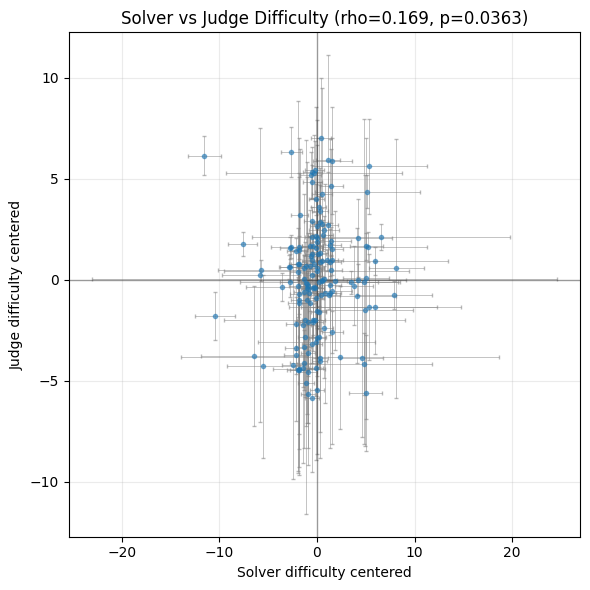

,solver_item_id,solver_pair_id,solver_source,solver_difficulty_centered,solver_difficulty_centered_laplace_se,judge_difficulty_centered,judge_difficulty_centered_laplace_se
0,7978,bd6f87f2-cb60-58b3-8b27-4eceab2bfc79,mmlu-pro-math,8.128340,2.824274,0.561482,6.431713
1,2934,6c5f9b09-193f-5070-9dfd-2dee1f69a9a3,mmlu-pro-biology,7.932643,3.846337,-0.747611,0.699099
2,9524,34e8d16b-9824-5373-b735-d25a3df21044,mmlu-pro-physics,6.580581,13.247175,2.106333,0.640650
3,1330,50e6565c-07f5-57d6-80d8-028498a1251b,mmlu-pro-law,5.959334,8.793365,-1.367597,2.313253
4,6222,1c76021c-cb8e-5477-8f7e-88855d6dd547,mmlu-pro-health,5.945632,7.515182,0.916554,0.708229


In [12]:
parttwo_difficulty_df = parttwo_table[[
    "solver_item_id",
    "solver_pair_id",
    "solver_source",
    "solver_difficulty_centered",
    "solver_difficulty_centered_laplace_se",
    "judge_difficulty_centered",
    "judge_difficulty_centered_laplace_se",
]].dropna().copy()

raw_rho, raw_p = spearmanr(
    parttwo_difficulty_df["solver_difficulty_centered"],
    parttwo_difficulty_df["judge_difficulty_centered"],
)
print(f"Spearman rho: {raw_rho:.4f}")
print(f"p-value:      {raw_p:.4g}")

plt.figure(figsize=(6, 6))
plt.errorbar(
    parttwo_difficulty_df["solver_difficulty_centered"],
    parttwo_difficulty_df["judge_difficulty_centered"],
    xerr=parttwo_difficulty_df["solver_difficulty_centered_laplace_se"],
    yerr=parttwo_difficulty_df["judge_difficulty_centered_laplace_se"],
    fmt="o",
    markersize=3,
    alpha=0.55,
    ecolor="gray",
    elinewidth=0.6,
    capsize=1.5,
)

plt.axhline(0, color="black", linewidth=1, alpha=0.35)
plt.axvline(0, color="black", linewidth=1, alpha=0.35)
plt.xlabel("Solver difficulty centered")
plt.ylabel("Judge difficulty centered")
plt.title(f"Solver vs Judge Difficulty (rho={raw_rho:.3f}, p={raw_p:.3g})")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(out_dir / f"mmlu_k{K}_solver_judge_difficulty_scatter.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / f"mmlu_k{K}_solver_judge_difficulty_scatter.pdf", bbox_inches="tight")
plt.show()

display(parttwo_difficulty_df.head())

parttwo_difficulty_df.to_csv(out_dir / f"mmlu_k{K}_solver_judge_difficulty_scatter.csv", index=False)
parttwo_difficulty_df.to_json(out_dir / f"mmlu_k{K}_solver_judge_difficulty_scatter.json", orient="records", indent=2, force_ascii=False)


## Solver Percentile vs Judge Percentile


Percentile Spearman rho: 0.1689
Percentile p-value:      0.03631


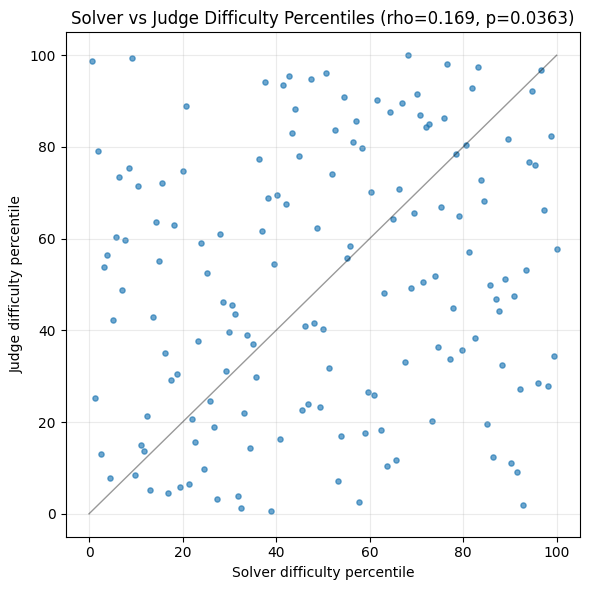

,solver_item_id,solver_pair_id,solver_source,solver_difficulty_centered,solver_difficulty_centered_laplace_se,judge_difficulty_centered,judge_difficulty_centered_laplace_se,solver_difficulty_percentile,judge_difficulty_percentile
0,7978,bd6f87f2-cb60-58b3-8b27-4eceab2bfc79,mmlu-pro-math,8.128340,2.824274,0.561482,6.431713,100.000000,57.792208
1,2934,6c5f9b09-193f-5070-9dfd-2dee1f69a9a3,mmlu-pro-biology,7.932643,3.846337,-0.747611,0.699099,99.350649,34.415584
2,9524,34e8d16b-9824-5373-b735-d25a3df21044,mmlu-pro-physics,6.580581,13.247175,2.106333,0.640650,98.701299,82.467532
3,1330,50e6565c-07f5-57d6-80d8-028498a1251b,mmlu-pro-law,5.959334,8.793365,-1.367597,2.313253,98.051948,27.922078
4,6222,1c76021c-cb8e-5477-8f7e-88855d6dd547,mmlu-pro-health,5.945632,7.515182,0.916554,0.708229,97.402597,66.233766


In [13]:
percentile_df = parttwo_difficulty_df.copy()
percentile_df["solver_difficulty_percentile"] = percentile_df["solver_difficulty_centered"].rank(pct=True) * 100
percentile_df["judge_difficulty_percentile"] = percentile_df["judge_difficulty_centered"].rank(pct=True) * 100

pct_rho, pct_p = spearmanr(
    percentile_df["solver_difficulty_percentile"],
    percentile_df["judge_difficulty_percentile"],
)
print(f"Percentile Spearman rho: {pct_rho:.4f}")
print(f"Percentile p-value:      {pct_p:.4g}")

plt.figure(figsize=(6, 6))
plt.scatter(
    percentile_df["solver_difficulty_percentile"],
    percentile_df["judge_difficulty_percentile"],
    s=14,
    alpha=0.65,
)
plt.plot([0, 100], [0, 100], color="black", linewidth=1, alpha=0.4)
plt.xlabel("Solver difficulty percentile")
plt.ylabel("Judge difficulty percentile")
plt.title(f"Solver vs Judge Difficulty Percentiles (rho={pct_rho:.3f}, p={pct_p:.3g})")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(out_dir / f"mmlu_k{K}_solver_judge_difficulty_percentiles.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / f"mmlu_k{K}_solver_judge_difficulty_percentiles.pdf", bbox_inches="tight")
plt.show()

display(percentile_df.head())

percentile_df.to_csv(out_dir / f"mmlu_k{K}_solver_judge_difficulty_percentiles.csv", index=False)
percentile_df.to_json(out_dir / f"mmlu_k{K}_solver_judge_difficulty_percentiles.json", orient="records", indent=2, force_ascii=False)
